### Build Changepoint detection model on TAQ Trades with adaptive penalties 

In [1]:
import pandas as pd 
import numpy as np
from scipy.sparse import dia_matrix, csc_matrix
from scipy.sparse.linalg import inv
import matplotlib.pyplot as plt
from datetime import datetime
import sys
from scipy.interpolate import interp1d
from scipy.stats import iqr
import ruptures as rpt
from sklearn.model_selection import train_test_split
import time




path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')
from adaptive_tf_ir import l1tf_adaptive_ir, Dmat

### TAQ Data AAPL

Snippet of AAPL trades on NYSE for 1 hour

In [2]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/cleaned_trades.csv',index_col=0)


trades=trades[trades.index < "2020-01-15 15:59:30"]
trades=trades[trades.index> "2020-01-15 15:55:00"]
trades
#trades['Trade_Price']=np.log(trades['Trade_Price'])


,SIP_Timestamp,Exchange,Symbol,Trade_Volume,Trade_Price,Sale_Condition,Source_of_Trade,Trade_Correction_Indicator,Sequence_Number,Trade_Id,Trade_Reporting_Facility,Trade_Through_Exempt_Indicator,date
2020-01-15 15:55:00.167778,2020-01-15 15:55:00.168158,N,AAPL,200,310.82,@F,N,0,2817965,5545,,1,2020-01-15
2020-01-15 15:55:00.527569,2020-01-15 15:55:00.527951,N,AAPL,100,310.85,@F,N,0,2818349,5546,,1,2020-01-15
2020-01-15 15:55:02.214288,2020-01-15 15:55:02.214671,N,AAPL,66,310.78,@ I,N,0,2819211,5547,,0,2020-01-15
2020-01-15 15:55:02.214497,2020-01-15 15:55:02.214876,N,AAPL,134,310.78,@F,N,0,2819222,5548,,1,2020-01-15
2020-01-15 15:55:02.218917,2020-01-15 15:55:02.219296,N,AAPL,105,310.81,@F,N,0,2819357,5549,,1,2020-01-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-15 15:59:25.573634,2020-01-15 15:59:25.574009,N,AAPL,46,311.19,@ I,N,0,2937032,5653,,0,2020-01-15
2020-01-15 15:59:26.015345,2020-01-15 15:59:26.015721,N,AAPL,40,311.20,@ I,N,0,2937404,5654,,0,2020-01-15
2020-01-15 15:59:29.176621,2020-01-15 15:59:29.177000,N,AAPL,97,311.22,@ I,N,0,2939443,5655,,0,2020-01-15
2020-01-15 15:59:29.920769,2020-01-15 15:59:29.921147,N,AAPL,100,311.27,@,N,0,2940442,5656,,0,2020-01-15


Text(0.5, 1.0, 'APPL Trade Price 01/15/2020')

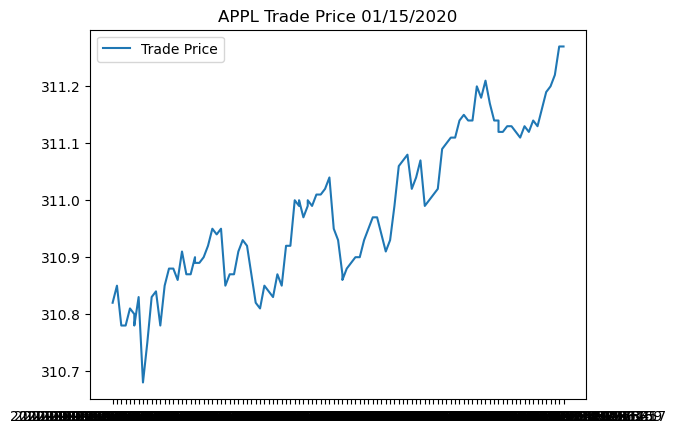

In [3]:
fig,ax=plt.subplots()
ax.plot(trades['Trade_Price'],label='Trade Price')
ax.legend()
ax.set_title("APPL Trade Price 01/15/2020")

In [4]:
vol=trades['Trade_Volume']

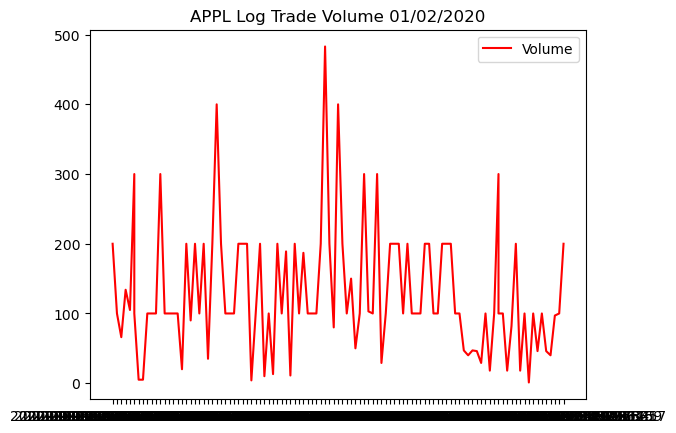

In [5]:
fig,ax=plt.subplots()
ax.set_title("APPL Log Trade Volume 01/02/2020")
ax.plot(vol,color='red',label='Volume')
ax.legend()

### Compute Max Lambda 

As denoted in L1 Trend Filtering, smallest maximum for which $\forall \lambda \geq \lambda_{max}$ the L1 trend filtering returns the best linear affine fit
$$\lambda_{max}=||(DD^T)^{-1}Dy||_\infty$$

For adaptiveness; one idea to show that the max of each component corresponds to the max of that single partition is that the trivial example of the best affine fit between two points simplify to linear interpolation

In [6]:
def max_norm(y,t=None,k=2,adaptive=False,verbose=True):
    
    '''
    
    Computes the smallest max penalty which provides a lower bound of linear affine fits 
    
    * For Efficiency uses scipy sparse matrices as datatype
    * Pascals triangle for fdm computation
    * Optimized returns similar as original but faster!!
    
    
    NEED TO CHANGE MAX_NORM FOR NEW D
    
    
    '''
    D=Dmat(len(y),k)
    
    if t is not None:
        
        t_diff=t
        t_diff1=np.pad(t_diff[1:] ,(0,1),'constant',constant_values=t_diff[-1])
        t_diff3=np.pad(t_diff[:-1],(0,1),'constant',constant_values=t_diff[-1])
        t_diff2=t_diff1+t_diff3 # error in composition 
            
        a=t_diff1/t_diff3
        b=-t_diff2/(t_diff1*t_diff3)
        c=t_diff3/t_diff1
            
        
        # project onto matrix
        T=dia_matrix((np.vstack([a,b,c]),[0,1,2]),shape=(len(y)-2,len(y))).toarray()
           
        # factor into our difference matrix 
        D=T
        
        D=csc_matrix(D)
    else:
        D.tocsc()
   
    D_DT=inv(D@D.T)
    
    
    if not adaptive:
        max_lam=abs(D_DT@D@y).max()
    else:
        max_lam=abs(D_DT@D@y)
        
    if verbose:
        print("Condition Number is ",np.linalg.cond((D@D.T).toarray()))
    return max_lam

In [7]:
lambda_val=max_norm(trades['Trade_Price'].values,k=2)
lambda_val

Condition Number is  5209171.478377961


/home/jbohn/miniconda3/envs/sepc/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:347: SparseEfficiencyWarning: splu converted its input to CSC format
  warn('splu converted its input to CSC format', SparseEfficiencyWarning)
/home/jbohn/miniconda3/envs/sepc/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:239: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '


19.54594317664396

In [8]:
lambda_val=max_norm(trades['Trade_Price'].values,2,True)
plt.title("Adaptive Penalty Bound")

plt.plot(trades['Trade_Price'].index[1:-1],lambda_val,label='Max Norm')
plt.legend()

TypeError: 'int' object is not subscriptable

### Apply Kernel Smoothing on Volume Time Series

Applies Kernel Spatial Smoothing s.t. 

$$\hat{Y}(x_j)=\frac{\sum_{t=1}^T K_\sigma(x_i,x_j)Y(x_i)}{\sum_{t=1}^T K_\sigma(x_i,x_j)}$$ 

Where our kernel function is the Gaussian Kernel

Or we can default to silvermans/scotts (however these have parametric assumptions)

In [ ]:
def compute_kernel(x_0,x_i,bandwidth):
    '''
    Given two points x_0 and x_i; compute the gaussian kernel utilizing euclidean distance 
    '''
    scale=abs((x_0-x_i)/bandwidth) # absolute distance in time
    
    weight= np.exp(-scale**2)
      
    return weight

def kernel_smooth(x0,series,pen,bw):
    '''
    x0: index of recent observation
    series: observations
    pen: max lambda to scale kernel to
    
    Note we use the asymptotically optimal bandwidth param for the Epan. Kernel


    '''
    num=0
    ker=0
    
    counter=0
    for index,val in series.items():
        
        kernel=compute_kernel(x0,index,bw) # compute weight as a function of time 
        ker+=kernel
     
        num+=kernel*val*pen[counter] # kernel smoothed series constrained by penalty 

        counter+=1

    return (num/ker)

In [ ]:
def smooth_series(k_series,p_series,t=None):
    
    '''
     
    Kernel Smooths a series using the gaussian kerenl
    
    i). Applies Min-Max Normalization to scale -> [0,1]
    ii). Applies Kernel Smoothing with penalty scaling-> [0,1]
    iii). Utilizes Scotts and Silvermans Bandwidth Selection Methods 
        

        
    '''
    
    smooth=[]
    
    
    pen=np.pad(max_norm(p_series.values,t=t,adaptive=True,verbose=False),(1,1))
    
    k_seconds=(k_series.index-k_series.index[0]).total_seconds() 
    normalized_data=(k_series.values-np.min(k_series.values))/(np.max(k_series.values)-np.min(k_series.values))
    
    normalized_series=pd.Series(normalized_data,index=k_seconds)
    
    silver_bw=0.9*min(np.std(k_series),iqr(k_series)/1.35)/(len(k_series)**0.2)
    scott_bw=1.06*np.std(k_series) / (len(k_series)**0.2)
    for x_i_index, x_i in normalized_series.items():
        smoothed_val=kernel_smooth(x_i_index,normalized_series,pen,scott_bw)
        smooth.append(smoothed_val)
   
    smooth=pd.Series(smooth,index=k_series.index)
    
        
    return smooth,pen

In [ ]:
smooth,pen=smooth_series(trades['Trade_Volume'],trades['Trade_Price'])

In [ ]:
scott_bw=1.06*np.std(trades['Trade_Volume']) / (len(trades['Trade_Volume'])**0.2)
print("Optimal BW is", scott_bw)

In [ ]:
fig,ax=plt.subplots(figsize=(10,8))
ax.plot(smooth.index,smooth.values,label='Kernel Smoothed Volume',color='green')

ax.set_title("Smoothed Volume")
ax2=ax.twinx()
ax2.plot(vol,color='red',label='Original Volume')
ax.legend()
ax2.legend(loc='upper left')

NameError: name 'smooth' is not defined

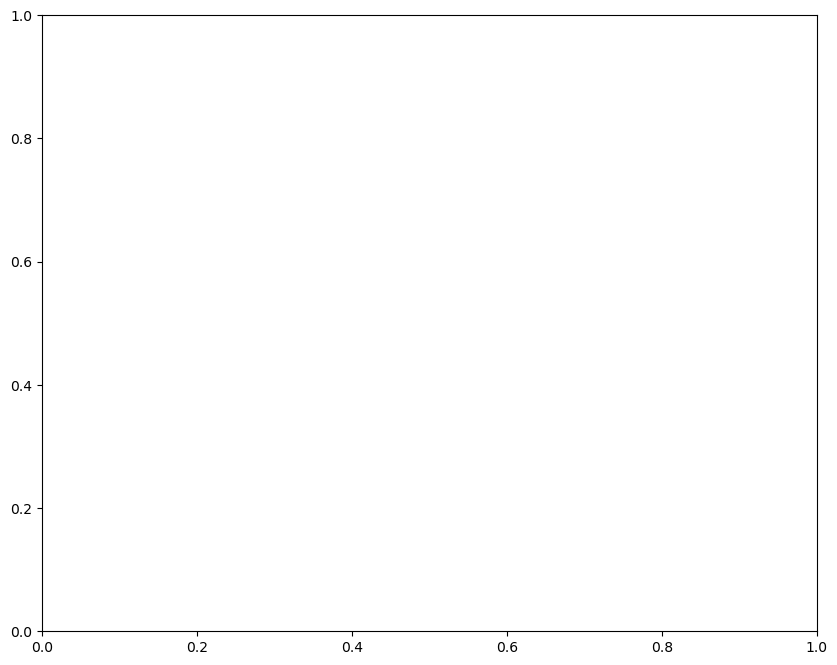

In [9]:
fig,ax=plt.subplots(figsize=(10,8))
ax.plot(smooth.index,smooth.values,label='Kernel Smoothed Volume',color='green')

ax.set_title("Comparison Smoothed Data to Penalty")
ax2=ax.twinx()
ax2.plot(smooth.index,pen,color='red',label='Max Norm')
ax.legend()
ax2.legend(loc='upper left')

### Extension for irregularly spaced time and Adaptive Penalty

### Unit Test 1

For both unit tests we pass in an array of differences in time 

For each trend filtering problem, the filtered signal is returned with the normalized D_DT Inverse



In [27]:
t=np.arange(0,len(trades.index))
t_new=np.pad(np.diff(t),(1,0),'constant',constant_values=t[1])

In [28]:

y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt1,status,eq_D,S1=l1tf_adaptive_ir(y,t=t_new,lambda_p=1.0)

solved


ValueError: not enough values to unpack (expected 4, got 3)

In [14]:


print(np.linalg.cond(eq_D))
print(np.round(eq_D,4))

27135748697059.22
[[ 13087.3498  38613.9794  75932.7841 ...  57941.4018  29358.6223
    9915.5175]
 [ 38613.9794 113938.703  224072.831  ... 171554.7265  86926.6023
   29358.6223]
 [ 75932.7841 224072.831  440697.4117 ... 338570.5971 171554.7265
   57941.4018]
 ...
 [ 57941.4018 171554.7265 338570.5971 ... 440697.4117 224072.831
   75932.7841]
 [ 29358.6223  86926.6023 171554.7265 ... 224072.831  113938.703
   38613.9794]
 [  9915.5175  29358.6223  57941.4018 ...  75932.7841  38613.9794
   13087.3498]]


Note the equivalence in difference matrix

Text(0.5, 1.0, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

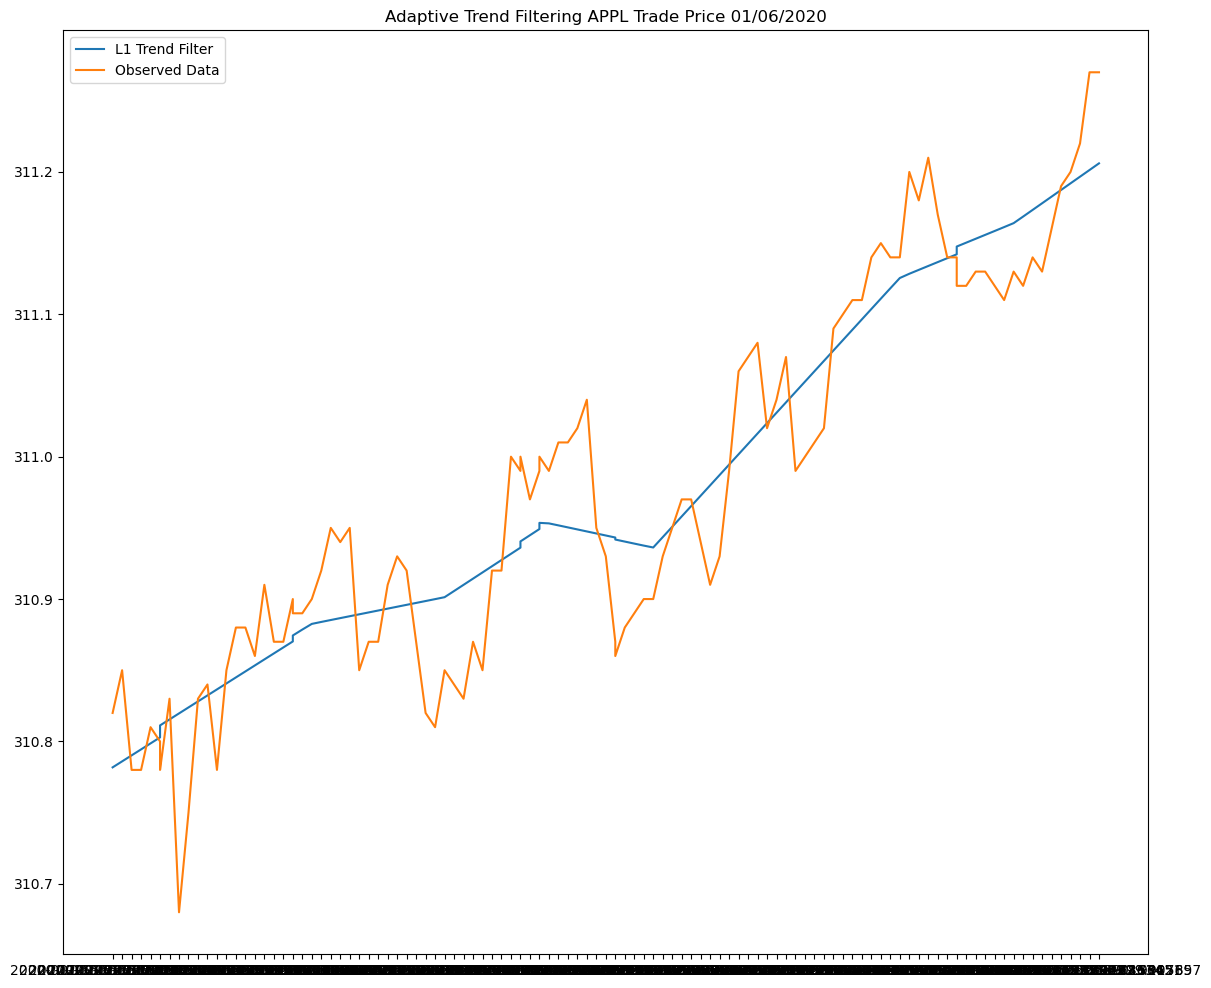

In [15]:
fig,ax=plt.subplots(figsize=(14,12))
ax.plot(trades.index,x_adapt1,label= 'L1 Trend Filter')
ax.plot(trades.index,y, label='Observed Data')


ax.legend()
ax.set_title("Adaptive Trend Filtering APPL Trade Price 01/06/2020")

### Unit Test 2

Uniformly sampled data within the range (0.999999,1.000001)

Leads me to believe the optimization is ill=conditioned 

In [16]:
a=0.9999
b=1.0001

t=np.random.rand(len(trades.index))*(b-a)+a


In [17]:

y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt2,status,D_2=l1tf_adaptive_ir(y,t=t,lambda_p=1.0)

solved


In [18]:


print(np.linalg.cond(D_2))
print(np.round(D_2,4))

27596151494958.3
[[ 13316.35    39293.9156  77290.904  ...  58880.9853  29829.5536
   10072.3427]
 [ 39293.9156 115957.5056 228104.947  ... 174351.6035  88328.5334
   29825.5224]
 [ 77290.904  228104.947  448749.0036 ... 344175.5518 174364.7007
   58877.4506]
 ...
 [ 58880.9853 174351.6035 344175.5518 ... 447027.603  227257.0014
   76996.4638]
 [ 29829.5536  88328.5334 174364.7007 ... 227257.0014 115540.3047
   39148.9501]
 [ 10072.3427  29825.5224  58877.4506 ...  76996.4638  39148.9501
   13266.0158]]


### Unit Test 3

In [19]:
a=0.99
b=1.01

t=np.random.rand(len(trades.index))*(b-a)+a

In [20]:


y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt3,status,D_3=l1tf_adaptive_ir(y,t=t,lambda_p=1.0)

solved


In [21]:


print(np.linalg.cond(D_3))
print(np.round(D_3,4))

26406686346275.99
[[7.81146910e+03 2.30358142e+04 4.47931579e+04 ... 1.33762090e+03
  5.41493700e+02 1.40723900e+02]
 [2.30358142e+04 6.79465292e+04 1.32150784e+05 ... 4.84149010e+03
  2.04475210e+03 5.66073700e+02]
 [4.47931579e+04 1.32150784e+05 2.57080789e+05 ... 1.12442087e+04
  4.88990010e+03 1.40899790e+03]
 ...
 [1.33762090e+03 4.84149010e+03 1.12442087e+04 ... 1.76683583e+05
  8.90940227e+04 3.03374389e+04]
 [5.41493700e+02 2.04475210e+03 4.88990010e+03 ... 8.90940227e+04
  4.49402024e+04 1.53072381e+04]
 [1.40723900e+02 5.66073700e+02 1.40899790e+03 ... 3.03374389e+04
  1.53072381e+04 5.21542520e+03]]


In [22]:
a=0
b=1

t=np.random.rand(len(trades.index))*(b-a)+a

In [23]:

y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt4,status,D_4=l1tf_adaptive_ir(y,t=t,lambda_p=1.0)

solved


In [24]:

print(np.linalg.cond(D_4))
print(np.round(D_4,4))

344108105708749.94
[[ 2.0144e+00  2.8662e+00  2.3250e+00 ... -0.0000e+00 -0.0000e+00
  -0.0000e+00]
 [ 2.8662e+00  4.0786e+00  3.3096e+00 ... -0.0000e+00 -0.0000e+00
  -0.0000e+00]
 [ 2.3250e+00  3.3096e+00  2.6977e+00 ... -0.0000e+00 -0.0000e+00
  -0.0000e+00]
 ...
 [-0.0000e+00 -0.0000e+00 -0.0000e+00 ...  1.0000e-04  3.0000e-04
   0.0000e+00]
 [-0.0000e+00 -0.0000e+00 -0.0000e+00 ...  3.0000e-04  7.0000e-04
   1.0000e-04]
 [-0.0000e+00 -0.0000e+00 -0.0000e+00 ...  0.0000e+00  1.0000e-04
   4.0000e-04]]


Text(0.5, 1.0, 'Equally Spaced with uniform +-1.0 noise ')

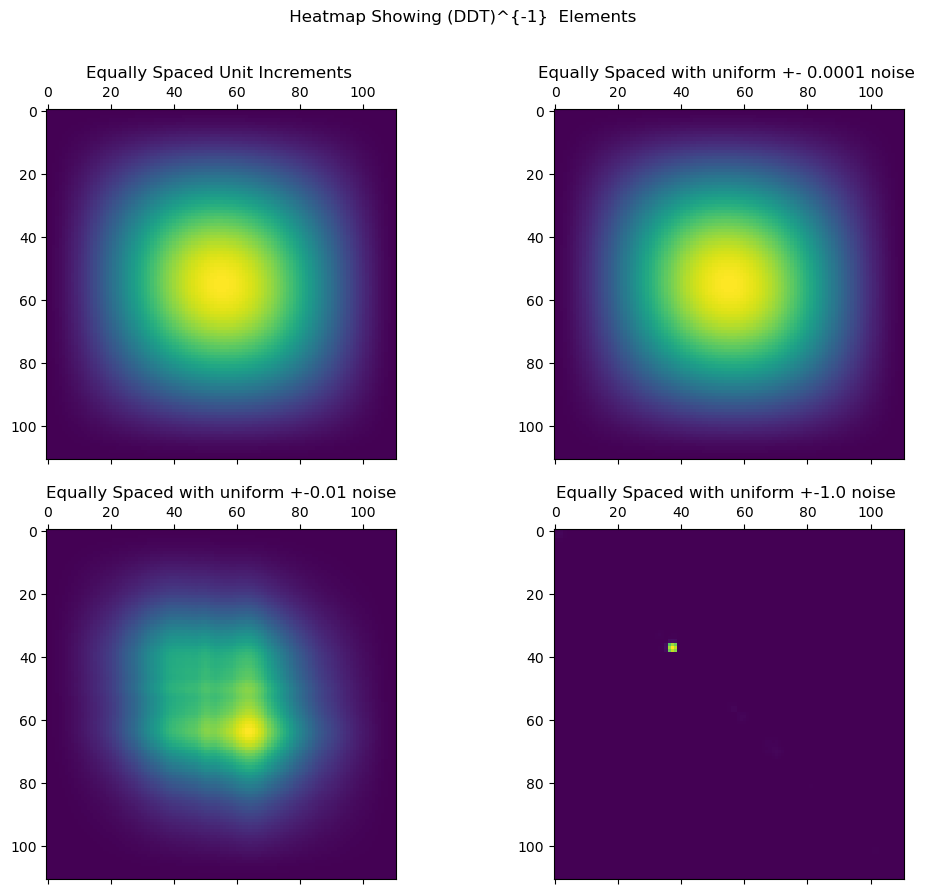

In [25]:
fig,ax=plt.subplots(2,2,figsize=(12,10))
fig.suptitle(" Heatmap Showing (DDT)^{-1}  Elements")
ax[0][0].matshow(eq_D)
ax[0][0].set_title("Equally Spaced Unit Increments ")
ax[0][1].matshow(D_2)
ax[0][1].set_title("Equally Spaced with uniform +- 0.0001 noise ")

ax[1][0].matshow(D_3)
ax[1][0].set_title("Equally Spaced with uniform +-0.01 noise")

ax[1][1].matshow(D_4)
ax[1][1].set_title("Equally Spaced with uniform +-1.0 noise ")



Text(0.5, 0.98, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

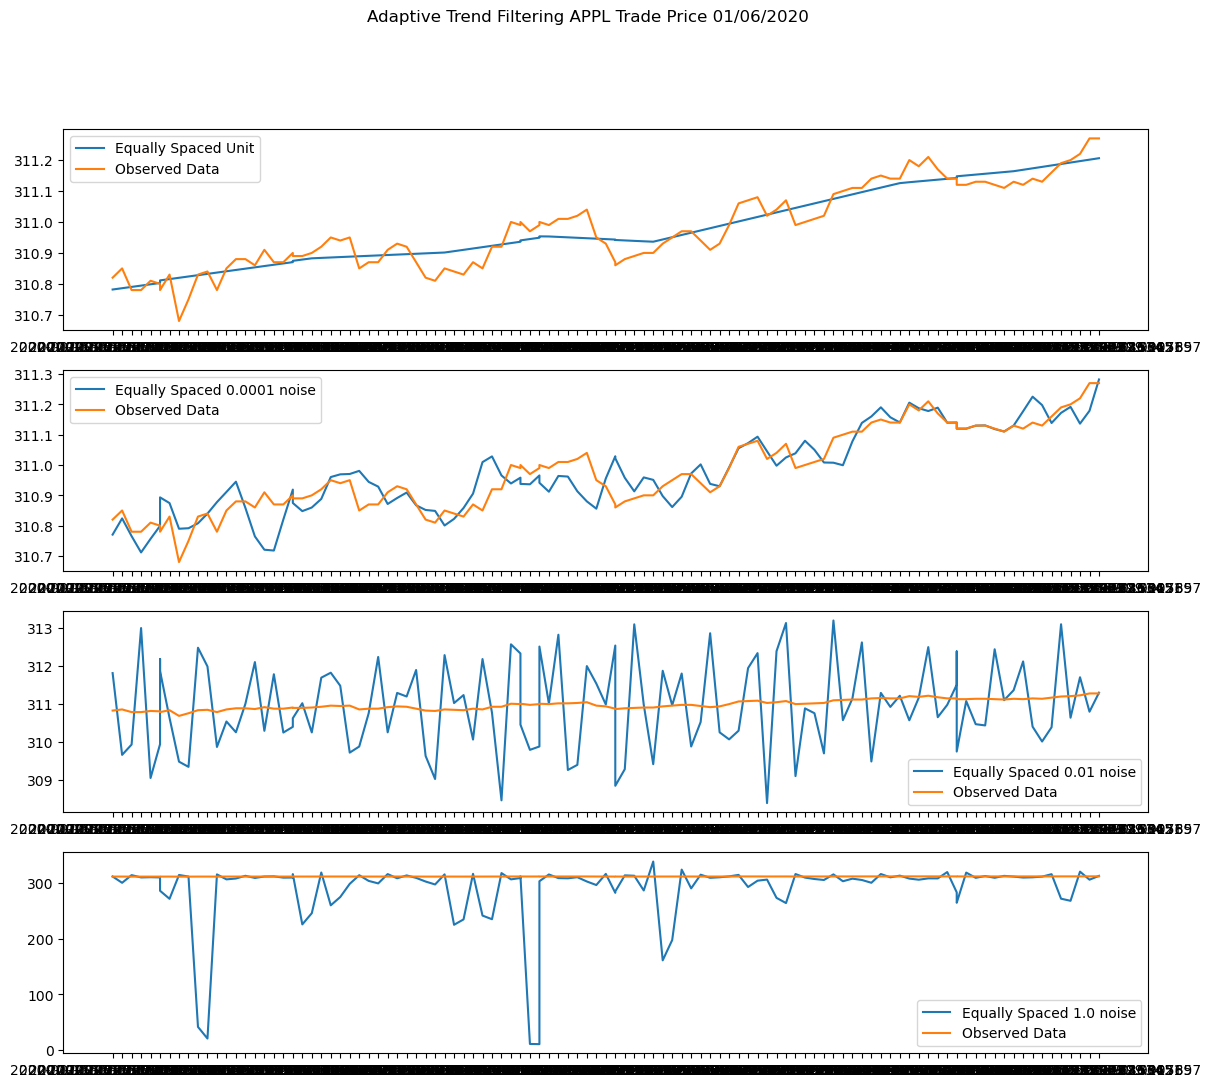

In [26]:
fig,ax=plt.subplots(4,1,figsize=(14,12))
ax[0].plot(trades.index,x_adapt1,label= 'Equally Spaced Unit')
ax[0].plot(trades.index,y, label='Observed Data')

ax[1].plot(trades.index,x_adapt2,label= 'Equally Spaced 0.0001 noise')
ax[1].plot(trades.index,y, label='Observed Data')

ax[2].plot(trades.index,x_adapt3,label= 'Equally Spaced 0.01 noise')
ax[2].plot(trades.index,y, label='Observed Data')

ax[3].plot(trades.index,x_adapt4,label= 'Equally Spaced 1.0 noise')
ax[3].plot(trades.index,y, label='Observed Data')

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

fig.suptitle("Adaptive Trend Filtering APPL Trade Price 01/06/2020")

### Updates from Analysis

- DDT_inv blows up in terms of magnitude
- Normalize by sup norm (max element ) seems to work in cases of small noise
- In large noise this ends up drownng out smaller values